In [19]:
import json
import os
import matplotlib.pyplot as plt

gaussian_base_dir = '/teamspace/studios/this_studio/gaussian_dataset/labels_dev/dev-test-tau'
base_dir = '/teamspace/studios/this_studio/data/labels_dev/dev-test-tau'
gaussain_jsons = os.listdir(gaussian_base_dir)
jsons = os.listdir(base_dir)

with open(os.path.join(base_dir,gaussain_jsons[0]), '+r') as f:
    contnt = json.load(f)

with open(os.path.join(gaussian_base_dir, gaussain_jsons[0]), "+r") as f:
    gaussian_contnt = json.load(f)



In [24]:

frame = contnt['annotations'][10]
gaussian_frame = gaussian_contnt['annotations'][10]

In [25]:
import numpy as np

frame_np = np.array(frame['segmentation'])
gaussian_np = np.array(gaussian_frame['segmentation'])

In [26]:
print(frame_np.shape, gaussian_np.shape)

(1, 1010, 3) (1, 5904, 3)


In [27]:
def _render_gaussian(h, w, points_vals, sigma_az=12, sigma_el=8):
    out = np.zeros((h, w), dtype=np.float32)
    yy, xx = np.mgrid[0:h, 0:w]
    for xi, yi, v in points_vals:
        g = v * np.exp(-((xx - xi)**2 / (2*sigma_az**2) + (yy - yi)**2 / (2*sigma_el**2)))
        np.maximum(out, g, out=out)
    return out

In [28]:
def create_frames(ann):
    img_w, img_h = 360, 180
    energy_map  = np.zeros((img_h, img_w), dtype=np.float32)

    for sub in ann["segmentation"]:
                for triplet in sub:
                    x, y, v = float(triplet[0]), float(triplet[1]), float(triplet[2])
                    xi, yi  = int(round(x)), int(round(y))
                    if 0 <= xi < img_w and 0 <= yi < img_h:
                        energy_map[yi, xi]      = float(v)
    
    return energy_map


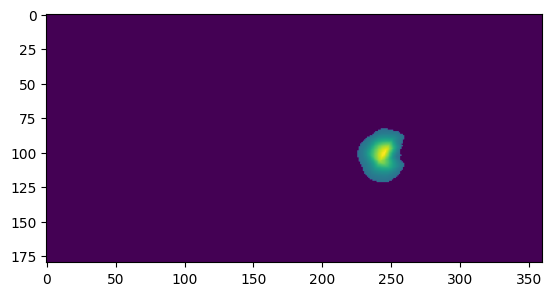

In [29]:
energy_map = create_frames(frame)

plt.imshow(energy_map)

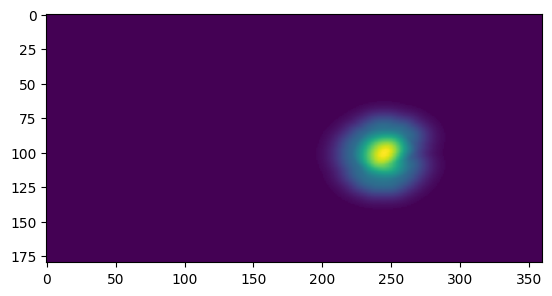

In [30]:
energy_map_gaussian = create_frames(gaussian_frame)

plt.imshow(energy_map_gaussian)